# Exercises - Estimating the Spot Curve

#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$

### Data

This exercise uses the data file, `treasury_quotes_2025-11-28`.

The problems below analyze the nominal, (rather than the TIPS,) Treasury issues. Accordingly, you should filter out all rows with `type` `TIPS Note` or `TIPS bond`.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_excel('../Data/treasury_quotes_2025-11-28.xlsx', sheet_name='selected quotes')
df

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,duration
0,208227,note,2025-11-28,2024-05-31,2026-05-31,0.503765,0.989071,4.875,100.521406,100.531220,100.526313,2.410861,102.937174,0.038263,7.142500e+10,0.492305
1,208316,note,2025-11-28,2024-11-30,2026-11-30,1.004791,0.989071,4.250,100.572266,100.591764,100.582015,2.101776,102.683791,0.036575,7.314900e+10,0.974601
2,208399,note,2025-11-28,2025-05-31,2027-05-31,1.503080,0.989071,3.875,100.453125,100.472656,100.462891,1.916325,102.379216,0.035621,7.844000e+10,1.448055
3,208484,note,2025-11-28,2025-11-30,2027-11-30,2.004107,0.000000,3.375,99.765625,99.769531,99.767578,0.000000,99.767578,0.034889,NaN,1.956136
4,208058,note,2025-11-28,2023-05-31,2028-05-31,2.505133,0.989071,3.625,100.312500,100.332031,100.322266,1.792691,102.114957,0.034901,4.936300e+10,2.376588
5,208145,note,2025-11-28,2023-11-30,2028-11-30,3.006160,0.989071,4.375,102.437500,102.472656,102.455078,2.163593,104.618671,0.035065,5.553400e+10,2.794544
6,208229,note,2025-11-28,2024-05-31,2029-05-31,3.504449,0.989071,4.500,103.171875,103.207031,103.189453,2.225410,105.414863,0.035258,7.415600e+10,3.218036
7,208318,note,2025-11-28,2024-11-30,2029-11-30,4.005476,0.989071,4.125,102.078125,102.132812,102.105469,2.039959,104.145428,0.035564,7.476100e+10,3.665596
8,208401,note,2025-11-28,2025-05-31,2030-05-31,4.503765,0.989071,4.000,101.730469,101.785156,101.757812,1.978142,103.735955,0.035754,7.958200e+10,4.092696
9,208486,note,2025-11-28,2025-11-30,2030-11-30,5.004791,0.000000,3.500,99.546875,99.554688,99.550781,0.000000,99.550781,0.035953,NaN,4.637183


# 1. Discount Rates

Use the data in the `selected quotes` tab.

Note:
* The selected treasuries are at nearly six-month intervals. 
* If you prefer, approximate that they mature at perfect 6-month intervals. 

### 1.1.

Create the cashflow matrix, $\textbf{C}$, where each rows is a Treasury issue, each column is a date, and each entry is the cash paid on a (normalized) face value of \$100.

In [ ]:
# Approximate maturities to exact 6-month intervals
df["n_periods"] = (df["ttm"] / 0.5).round().astype(int)

# Semiannual coupon per $100 face value
df["coupon"] = 100 * df["cpn rate"] / 100 / 2

# Time grid (columns)
max_periods = df["n_periods"].max()
times = np.arange(1, max_periods + 1) * 0.5

# Initialize cashflow matrix
C = pd.DataFrame(
    0.0,
    index=df["KYTREASNO"],
    columns=times
)

# Populate cashflows
for _, row in df.iterrows():
    n = row["n_periods"]
    coupon = row["coupon"]
    # Coupons
    C.loc[row["KYTREASNO"], times[:n]] = coupon
    # Principal at maturity
    C.loc[row["KYTREASNO"], times[n-1]] += 100
C

,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5,10.0
KYTREASNO,,,,,,,,,,,,,,,,,,,,
208227,102.4375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208316,2.1250,102.1250,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208399,1.9375,1.9375,101.9375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208484,1.6875,1.6875,1.6875,101.6875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208058,1.8125,1.8125,1.8125,1.8125,101.8125,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208145,2.1875,2.1875,2.1875,2.1875,2.1875,102.1875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208229,2.2500,2.2500,2.2500,2.2500,2.2500,2.2500,102.2500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208318,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,102.0625,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208401,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,102.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0


### 1.2.

Estimate the spot discount factors that rationalize the market prices of the treasuries. Do this via solving the linear system

$$\textbf{p} = {\textbf{C}}\, \textbf{z}$$

In [28]:
# Price vector p (clean prices per $100 face)
p = df.set_index("KYTREASNO")["price"]
# Solve linear system using least squares (robust if overdetermined)
z, residuals, rank, s = np.linalg.lstsq(C.values, p.values, rcond=None)
# Put discount factors into a labeled Series
z = pd.Series(z, index=times, name="discount_factor")
z

0.5     0.981343
1.0     0.964472
1.5     0.948551
2.0     0.933088
2.5     0.917225
3.0     0.901050
3.5     0.884954
4.0     0.868448
4.5     0.852545
5.0     0.836465
5.5     0.818640
6.0     0.801868
6.5     0.784631
7.0     0.767992
7.5     0.750850
8.0     0.735044
8.5     0.718142
9.0     0.700921
9.5     0.684347
10.0    0.668448
Name: discount_factor, dtype: float64

### 1.3.

Plot the time-to-maturity on the horizontal axis. On the vertical axis, plot the...
* discount factors

Make another plot, this time with the vertical axis displaying the
* semiannually compounded discount rates
* continuously compounded discount rates

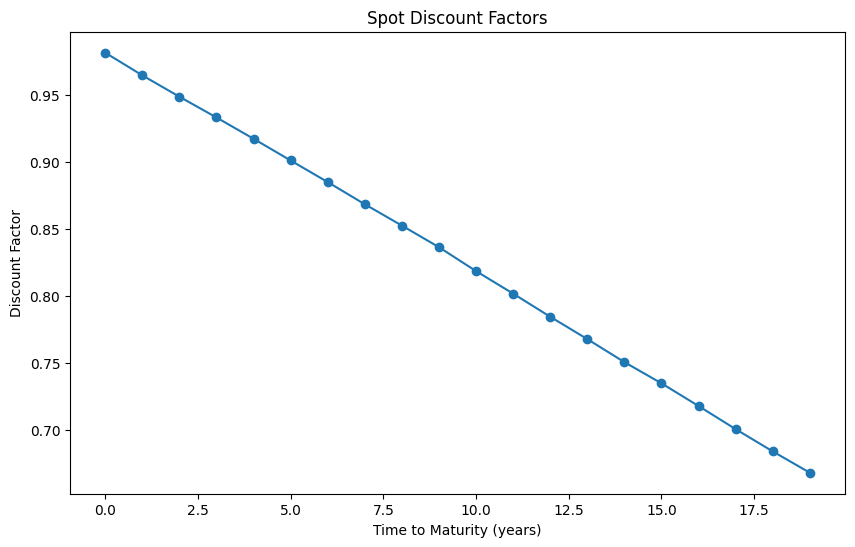

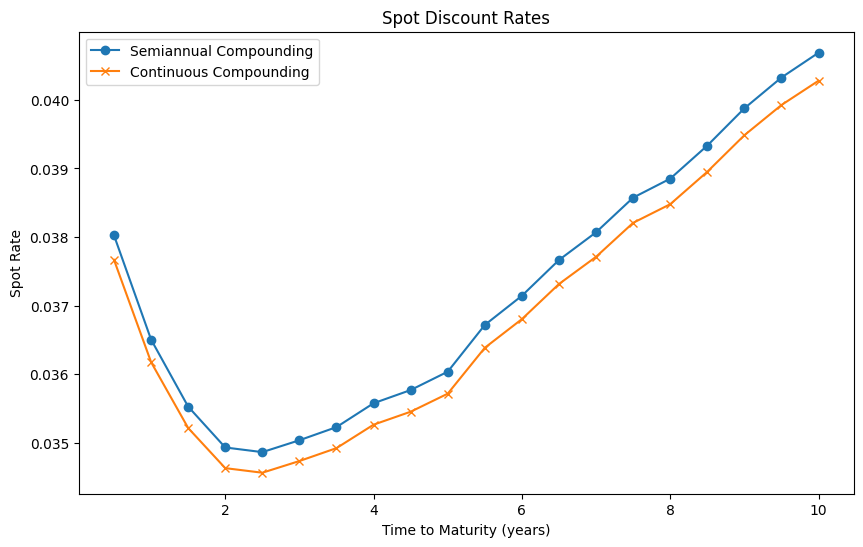

In [36]:
# plot 1 
figure = plt.figure(figsize=(10,6))
plt.plot(z, marker='o')
plt.xlabel("Time to Maturity (years)")
plt.ylabel("Discount Factor")
plt.title("Spot Discount Factors")
plt.show()

# plot 2
# Semiannual-compounded spot rate
r_sa = 2 * (z ** (-1 / (2 * times)) - 1)
# Continuously-compounded spot rate
r_cc = -np.log(z) / times
figure = plt.figure(figsize=(10,6))
plt.plot(times, r_sa, marker='o', label="Semiannual Compounding")
plt.plot(times, r_cc, marker='x', label="Continuous Compounding")
plt.xlabel("Time to Maturity (years)")
plt.ylabel("Spot Rate")
plt.title("Spot Discount Rates")
plt.legend()
plt.show()

### 1.4. Curve-Fitting

Estimate the discount curve via the Nelson-Siegel model.
* Fit via minimizing the sum of squared errors of the modeled prices against the quoted prices.
* Consider using `minimize` from `scipy.optimize`.

When done,
* Report the estimated NS parameters.
* Plot the semiannually-compounded discount rates along with those estimated with OLS from above.

Nelson–Siegel parameters
beta0 = 0.05131
beta1 = -0.01217
beta2 = -0.03272
tau   = 2.57093


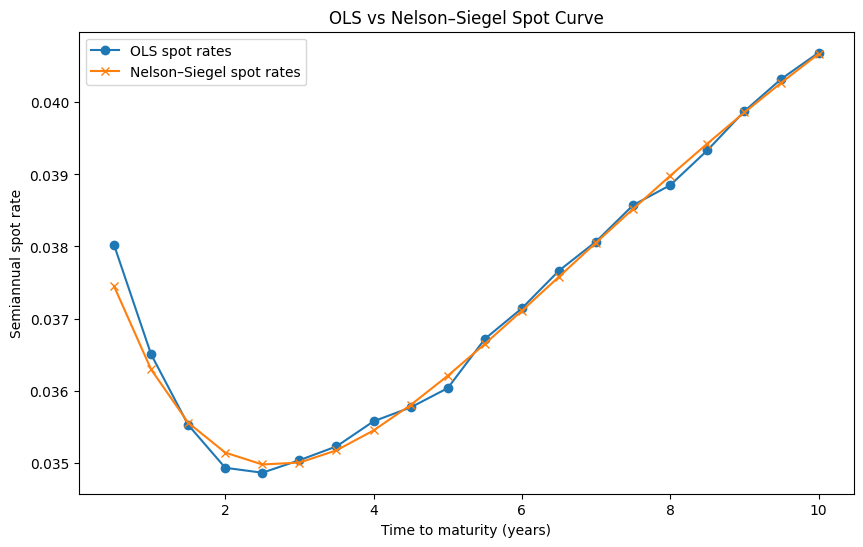

In [38]:
from scipy.optimize import minimize

# Nelson–Siegel functions
def ns_yield(t, beta0, beta1, beta2, tau):
    f1 = (1 - np.exp(-t / tau)) / (t / tau)
    f2 = f1 - np.exp(-t / tau)
    return beta0 + beta1 * f1 + beta2 * f2

def ns_discount(params):
    y = ns_yield(times, *params)
    return (1 + y / 2) ** (-2 * times)

# Price-based objective
def price_sse(params):
    z = ns_discount(params)
    return np.sum((C.values @ z - p) ** 2)

# Estimate NS parameters
x0 = [0.03, -0.02, 0.02, 2.0]
bounds = [(0, 0.10), (-0.10, 0.10), (-0.10, 0.10), (0.1, 10)]

res = minimize(price_sse, x0, bounds=bounds)
beta0, beta1, beta2, tau = res.x

print("Nelson–Siegel parameters")
print(f"beta0 = {beta0:.5f}")
print(f"beta1 = {beta1:.5f}")
print(f"beta2 = {beta2:.5f}")
print(f"tau   = {tau:.5f}")

# Plot: OLS vs NS spot curves
# OLS discount factors from Section 1.2
z_ols = np.linalg.lstsq(C.values, p, rcond=None)[0]
r_ols = 2 * (z_ols ** (-1 / (2 * times)) - 1)
r_ns = ns_yield(times, beta0, beta1, beta2, tau)
figure = plt.figure(figsize=(10,6))
plt.plot(times, r_ols, marker='o', label="OLS spot rates")
plt.plot(times, r_ns, marker='x', label="Nelson–Siegel spot rates")
plt.xlabel("Time to maturity (years)")
plt.ylabel("Semiannual spot rate")
plt.title("OLS vs Nelson–Siegel Spot Curve")
plt.legend()
plt.show()

***

# 2. Estimating the Discount Curve with Non-Evenly Spaced Data

Use the data in the `quotes` tab.

### 2.1. Map Cashflows

Construct the cashflow matrix.

Given the unfiltered data set, you will need to make a few modeling choices to do this...
* eliminate any treasury that does not report YTM or that reports a negative YTM.
* assume notes and bonds pay coupons every six months, going backward from the date of maturity.

Make other reasonable modeling assumptions as needed.

Report:
* head and tail rows of the dataframe, $\textbf{C}$, for instance, using `display()`.

* which date has the most cashflow across all issues?

* which date has the most issues paying a cashflow?

In [43]:
df = pd.read_excel('../Data/treasury_quotes_2025-11-28.xlsx', sheet_name='quotes')

# Remove TIPS
df = df[~df["type"].isin(["TIPS Note", "TIPS bond"])]
# Remove missing or negative YTM
df = df[df["ytm"].notna()]
df = df[df["ytm"] >= 0]

df = df.copy()
df

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,duration
0,208422,bill,2025-11-28,2025-08-05,2025-12-02,0.010951,NaN,0.000,99.989146,99.989174,99.989160,0.000000,99.989160,0.009924,2.657700e+11,0.010959
1,208397,bill,2025-11-28,2025-06-05,2025-12-04,0.016427,NaN,0.000,99.967491,99.967574,99.967532,0.000000,99.967532,0.019866,2.514150e+11,0.016438
2,208432,bill,2025-11-28,2025-08-12,2025-12-09,0.030116,NaN,0.000,99.913089,99.913311,99.913200,0.000000,99.913200,0.029043,2.707090e+11,0.030137
3,208410,bill,2025-11-28,2025-06-12,2025-12-11,0.035592,NaN,0.000,99.891417,99.891694,99.891556,0.000000,99.891556,0.030719,2.552590e+11,0.035616
4,207988,note,2025-11-28,2022-12-15,2025-12-15,0.046543,0.907104,4.000,99.998315,99.998711,99.998513,1.814208,101.812721,0.039877,3.999900e+10,0.046575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,208322,bond,2025-11-28,2024-11-15,2054-11-15,28.963723,0.071823,4.500,97.199219,97.257812,97.228516,0.161602,97.390118,0.046760,8.006300e+10,16.261140
451,208362,bond,2025-11-28,2025-02-15,2055-02-15,29.215606,0.570652,4.625,99.246094,99.300781,99.273437,1.319633,100.593071,0.046705,7.990100e+10,16.056723
452,208405,bond,2025-11-28,2025-05-15,2055-05-15,29.459274,0.071823,4.750,101.296875,101.359375,101.328125,0.170580,101.498705,0.046673,8.080300e+10,16.217796
453,208448,bond,2025-11-28,2025-08-15,2055-08-15,29.711157,0.570652,4.750,101.328125,101.390625,101.359375,1.355299,102.714674,0.046650,7.787900e+10,16.100166


In [46]:
# Convert dates
df["maturity"] = pd.to_datetime(df["maturity date"])
df["asof"] = pd.to_datetime(df["quote date"])

# Semiannual coupon per $100 face
df["coupon"] = 100 * df["cpn rate"] / 100 / 2

def coupon_dates(maturity, asof):
    dates = []
    d = maturity
    while d > asof:
        dates.append(d)
        d = d - pd.DateOffset(months=6)
    return dates

# Collect all cashflow dates
all_dates = set()
cashflows = {}

for _, row in df.iterrows():
    dates = coupon_dates(row["maturity"], row["asof"])
    flows = {}
    for d in dates:
        flows[d] = row["coupon"]
    # Add principal at maturity
    if row["maturity"] in flows:
        flows[row["maturity"]] += 100
    cashflows[row["KYTREASNO"]] = flows
    all_dates.update(dates)

# Sort dates
all_dates = sorted(all_dates)

# Build cashflow matrix
C = pd.DataFrame(0.0, index=cashflows.keys(), columns=all_dates)
for bond, flows in cashflows.items():
    for d, amt in flows.items():
        C.loc[bond, d] = amt

from IPython.display import display

display(C.head())
display(C.tail())

,2025-11-30,2025-12-02,2025-12-04,2025-12-09,2025-12-11,2025-12-15,2025-12-16,2025-12-18,2025-12-23,2025-12-26,...,2053-08-15,2053-11-15,2054-02-15,2054-05-15,2054-08-15,2054-11-15,2055-02-15,2055-05-15,2055-08-15,2055-11-15
208422,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208397,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208432,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208410,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
207988,0.0,0.0,0.0,0.0,0.0,102.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,2025-11-30,2025-12-02,2025-12-04,2025-12-09,2025-12-11,2025-12-15,2025-12-16,2025-12-18,2025-12-23,2025-12-26,...,2053-08-15,2053-11-15,2054-02-15,2054-05-15,2054-08-15,2054-11-15,2055-02-15,2055-05-15,2055-08-15,2055-11-15
208322,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,2.2500,0.0000,2.2500,0.0000,102.2500,0.0000,0.0000,0.000,0.0000
208362,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.3125,0.0000,2.3125,0.0000,2.3125,0.0000,102.3125,0.0000,0.000,0.0000
208405,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,2.3750,0.0000,2.3750,0.0000,2.3750,0.0000,102.3750,0.000,0.0000
208448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.3750,0.0000,2.3750,0.0000,2.3750,0.0000,2.3750,0.0000,102.375,0.0000
208490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,2.3125,0.0000,2.3125,0.0000,2.3125,0.0000,2.3125,0.000,102.3125


In [52]:
# Find the column with the largest sum
largest_sum_column = C.sum().idxmax()

# Find the column with the most non-zero entries
most_nonzero_column = (C != 0).sum().idxmax()

print(f"Date paying the most cash: {largest_sum_column:%Y-%m-%d}")
print(f"Date with the most paying bonds: {most_nonzero_column:%Y-%m-%d}")

Date paying the most cash: 2026-04-30
Date with the most paying bonds: 2026-02-15


### 2.2. OLS

Estimate the discount factors using OLS.

Starting with the cashflow matrix, $C$, create an additional filter to get a subset where every date has at least one maturity, (possibly multiple,) and every issue has its maturity in the cashflow matrix. Call this set of cashflows, $\hat{C}$.

**Report 5 head and tail rows of $\hat{C}$.**

$$\textbf{p} = \hat{\textbf{C}}\,\textbf{z}_{\text{ols}}+\epsilon$$

Plot the time-to-maturity vs discount rates, semiannually compounded.

In [ ]:
# Step 1: Identify maturity dates (columns with principal repayment)
maturity_mask = (C >= 100).any(axis=0)
valid_dates = maturity_mask[maturity_mask].index

# Step 2: Keep only issues whose maturity appears in the matrix
valid_issues = (C.loc[:, valid_dates] >= 100).any(axis=1)

C_hat = C.loc[valid_issues, valid_dates]
p_hat = p.loc[valid_issues]

display(C_hat.head())
display(C_hat.tail())

# Step 4: OLS estimation of discount factors
z_ols = np.linalg.lstsq(C_hat.values, p_hat.values, rcond=None)[0]
z_ols = pd.Series(z_ols, index=C_hat.columns, name="discount_factor")


# Step 5: Convert discount factors to semiannual spot rates
asof = df["quote date"].iloc[0]
times = (z_ols.index - asof).days / 365.25

r_ols = 2 * (z_ols.values ** (-1 / (2 * times)) - 1)

# Step 6: Plot term structure
plt.figure()
plt.plot(times, r_ols, marker='o')
plt.xlabel("Time to Maturity (years)")
plt.ylabel("Semiannual Spot Rate")
plt.title("OLS-Implied Semiannual Spot Rates")
plt.show()

### 2.3. Nelson-Siegel Curve-Fitting

As in `1.4`, estimate the Nelson-Siegel curve.

In [55]:
def nelson_siegel_rate(t, beta0, beta1, beta2, tau):
    term1 = (1 - np.exp(-t / tau)) / (t / tau)
    term2 = term1 - np.exp(-t / tau)
    return beta0 + beta1 * term1 + beta2 * term2

# ------------------------------------------------------------
# Price-implied discount factors from NS parameters
# ------------------------------------------------------------
def ns_discount_factors(params, times):
    beta0, beta1, beta2, tau = params
    r = nelson_siegel_rate(times, beta0, beta1, beta2, tau)
    return (1 + r / 2) ** (-2 * times)

# ------------------------------------------------------------
# Objective: SSE between model prices and market prices
# ------------------------------------------------------------
def ns_objective(params, C, prices, times):
    z = ns_discount_factors(params, times)
    model_prices = C @ z
    return np.sum((model_prices - prices) ** 2)

# ------------------------------------------------------------
# Parameter estimation
# ------------------------------------------------------------
initial_guess = np.array([0.03, -0.02, 0.02, 1.5])
bounds = [(0, None), (None, None), (None, None), (0.05, None)]

result = minimize(
    ns_objective,
    initial_guess,
    args=(C_hat.values, p_hat.values, times),
    bounds=bounds
)

beta0, beta1, beta2, tau = result.x

print("Nelson–Siegel Parameter Estimates")
print(f"beta0 = {beta0:.6f}")
print(f"beta1 = {beta1:.6f}")
print(f"beta2 = {beta2:.6f}")
print(f"tau   = {tau:.6f}")

# ------------------------------------------------------------
# Compare NS vs OLS semiannual spot curves
# ------------------------------------------------------------
r_ns = nelson_siegel_rate(times, beta0, beta1, beta2, tau)

plt.figure()
plt.plot(times, r_ols, marker='o', label="OLS Spot Rates")
plt.plot(times, r_ns, marker='x', label="Nelson–Siegel Spot Rates")
plt.xlabel("Time to Maturity (years)")
plt.ylabel("Semiannually Compounded Spot Rate")
plt.title("Treasury Spot Curve: OLS vs Nelson–Siegel")
plt.legend()
plt.show()


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 20 is different from 270)

### 2.4. Weighted Least Squares

Re-do `2.2.`, but this time use Weighted Least Squares. Find a weighting scheme that puts more weight on more recently issued treasures and less weight on less recently issued treasures. 

Does your answer change much?


***